# **Attempt using `torch.register_module_forward_hook` built-in**

Python allows for a builtin storage of internal values. This is done via the `register_module_forward_hook` built-in method, even though I never actually used this.

Be aware that I run this experiment on a MacOS machine, hence I used MPS-related content. Everything works just as fine if one decides to work with CUDA. Actually the only thing that one has to change should be the utils functions that describe memory usage. This was done since MPS allows for a lesser amount of builtins that describe internal status.

## **BUIILDING THE HOOKS**

The following chunk defines a basic hook skeleton that:
- dynamically moves the layer to and through CPU/GPU
- checks VRAM GPU memory usage at each layer

The so-designed hooks are designed as classes in order to allow for inheritance if minor changes are to be considered in the future. There also is an example of such technique since 

In [2]:
from torch.cuda import is_available as cuda_is_available
from torch.mps import is_available as mps_is_available
import torch.mps as mps
from torch.nn import Module
from torch import Tensor

from typing import Literal
Device = Literal['cpu', 'mps', 'cuda']

class HookForLanguageModel:
    '''General instructions for hooks common among all different language model(s). These mostly include dynamic movement of the layer to allow for larger parallelization'''

    def __init__(self) -> None:
        self.device = self._get_device()
    ##

    @staticmethod
    def _get_device() -> Device:
        if cuda_is_available():
            return 'cuda'
        elif mps_is_available():
            return 'mps'
        else:
            return 'cpu'
    ##

    def pre_forward_hook(
            self, 
            module: Module, 
            input: Tensor
        ):
        '''Define behaviour before the training loop'''
        # input.to(self.device)
        module.to(self.device)
        mps.synchronize()
        mps.empty_cache()
        return input
    ##

    def forward_hook(
            self, 
            module: Module, 
            input: Tensor, 
            output: Tensor,
        ):
        '''Happens after a forward() call has been completed'''
        mps.synchronize()
        mps.empty_cache()
        module.to('cpu')
        # input.to('cpu')
        return output
    ##
##

class HookForLanguageModelWithMemoryRecording(HookForLanguageModel):
    def __init__(self) -> None:
        super().__init__()
        self._peak_memory_usage = 0
    ##

    @property
    def peak_memory_usage_MB(self):
        'Returns the same values, but in MB instead of bytes'
        return self._peak_memory_usage // (1024**2)
    @property
    def peak_memory_usage_GB(self):
        'Returns the same values, but in MB instead of bytes'
        return self._peak_memory_usage // (1024**3)
    ##

    def _reset(self):
        self._peak_memory_usage = 0
    ##

    def forward_hook(self, *args, **kwargs):
        '''Adds the possibility to record the peak memory usage. We record memory usage without really caring about the input size, since that should not be the bottleneck'''
        self._peak_memory_usage = max(mps.current_allocated_memory(), self._peak_memory_usage)
        super().forward_hook(*args, **kwargs)
    ##
##

## **INTRO**
Nothing interesting here, just some utils definition and the loading of model + tokenizer

### **UTILS FUNCTIONS**

In [6]:
## UTILS FUNCTIONS
from torch.mps import recommended_max_memory, current_allocated_memory
from transformers import AutoModelForCausalLM, AutoTokenizer

def _recommended_max_memory():
    '''Thought to output the result in GB, instead of classic bytes'''
    return recommended_max_memory() / (1024**3)
##

def _current_allocated_memory():
    return current_allocated_memory() / (1024**3)
##

def _mps_usage_percentage():
    return 100 * current_allocated_memory() / recommended_max_memory()
##

def _get_mps_status() -> None:
    print(f'Recommended max memory usage for this machine: {_recommended_max_memory():.2f}GB')
    print(f'Currently allocated MPS memory: {_current_allocated_memory():.2f}GB - {_mps_usage_percentage():.2f}%')
##

_get_mps_status()

Recommended max memory usage for this machine: 24.96GB
Currently allocated MPS memory: 0.07GB - 0.26%


### **LOADING THE MODEL**

In [4]:
## LOADING THE MODEL (TO CPU - STANDARD) ##
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
print(f'\nImporting model: {MODEL_NAME}')
llama_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path= MODEL_NAME,
    device_map = 'cpu',
)
llama_tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME
)


Importing model: meta-llama/Llama-3.1-8B-Instruct


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 5370.59it/s]


I emphasize that the auto-loading of the model does not come with automatic hooks support, since `transformers` does not provide for them. Hence, one must manually assign hooks to layers.

This is another feature that would be useful to abstract in the final version of the project.

## **EXPERIMENTS**

In this section we perform a couple of experiments that aim to show major differences that happen when using hooks and while not. Moreover, the no hooks demo will be tested on both CPU and GPU storage.

We will (hopefully) perform the experiments on different batches size: since we expect hooks to slow down unparalleled operations mostly because loading data to/from GPUs is the real bottleneck of the computation. However, if we can use the space that we saved with the hooks to perform parallel computation, larger batch size should really let the hooks utilities emerge.

Before performing the main cell (with the basic experiment), ensure your GPU device is as empty as possible.

In [5]:
_get_mps_status()

Recommended max memory usage for this machine: 24.96GB
Currently allocated MPS memory: 0.00GB - 0.00%


If the usage is close to ~0.00%, then feel free to run the following

In [8]:
######################################
### EXPERIMENT WITH BATCH SIZE = 1 ###
######################################

import time
from torch import inference_mode
from json import load

## DATA LOADING ##
FILE_PATH = '/Users/simone/Desktop/projects/llm-steering-experiment/datasets/anthropic/train/sycophancy.json'
with open(FILE_PATH, 'r') as f:
    data = load(f)

## ASSIGN HOOKS TO LAYER ## 
hooks = HookForLanguageModelWithMemoryRecording()
handles = []

for name, module in llama_model.named_modules():
    if len(list(module.children())) == 0:
        handles.append(module.register_forward_pre_hook(hooks.pre_forward_hook))
        handles.append(module.register_forward_hook(hooks.forward_hook))

# print(f'total number of assigned hooks: {len(handles)}')

## COMMON VARIABLES DECLARATION ## 
prompt = data[0]['question']
prompt_matching = prompt + data[0]['answer_matching_behavior']
prompt_not_matching = prompt + data[0]['answer_not_matching_behavior']

inputs = llama_tokenizer(prompt_matching, return_tensors='pt')
inputs.to('mps')

## COMPUTATION WITH HOOKS ## 
with inference_mode():
    t_0 = time.perf_counter()
    llama_model(**inputs)
    t_end = time.perf_counter()
inputs.to('cpu')

print(f'\nMax memory used during forward phase with hooks: {hooks.peak_memory_usage_MB} MB')
print(f'Time needed to perform the forward phase {t_end - t_0} seconds')

## REMOVING THE HOOKS FROM THE MODEL
for hook in handles:
    hook.remove()
hooks._reset()

## PERFORMING COMPUTATION WITHOUT HOOKS - ON GPU
llama_model.to('mps')
inputs.to('mps')

with inference_mode():
    t_0 = time.perf_counter()
    llama_model(**inputs)
    t_end = time.perf_counter()

print(f'\nMax memory used during forward phase without hooks, model on {llama_model.device}: {mps.current_allocated_memory() / (1024**2)} MB')
print(f'Time needed to perform the forward phase {t_end - t_0} seconds')

## PERFORMING COMPUTATION WITHOUT HOOKS - ON CPU
llama_model.to('cpu')
inputs.to('cpu')

with inference_mode():
    t_0 = time.perf_counter()
    llama_model(**inputs)
    t_end = time.perf_counter()


print(f'\nMax memory used during forward phase without hooks, model on {llama_model.device}: {mps.current_allocated_memory() / (1024**2)} MB')
print(f'Time needed to perform the forward phase {t_end - t_0} seconds')

## FINAL CHECK ON MPS USAGE: should return to configuration status ##
print()
_get_mps_status()



Max memory used during forward phase with hooks: 1071 MB
Time needed to perform the forward phase 25.977383457997348 seconds

Max memory used during forward phase without hooks, model on mps:0: 15352.041015625 MB
Time needed to perform the forward phase 0.9896432909954456 seconds

Max memory used during forward phase without hooks, model on cpu: 0.0 MB
Time needed to perform the forward phase 22.87521820799884 seconds

Recommended max memory usage for this machine: 24.96GB
Currently allocated MPS memory: 0.00GB - 0.00%


Conclusion: could debug the structure of `input` to further tweak situations and maximize performance.

### Pre-determining size of full dataset
We do this due to possible excessive memory usage while running parallel computation

In [6]:
from json import load

## DATA LOADING ##
FILE_PATH = '/Users/simone/Desktop/projects/llm-steering-experiment/datasets/anthropic/train/sycophancy.json'
with open(FILE_PATH, 'r') as f:
    data = load(f)

## DATA FORMATTING ##    
prompts_matching = [row['question'] + row['answer_matching_behavior'] for row in data]
prompts_not_matching = [row['question'] + row['answer_not_matching_behavior'] for row in data]
prompts = prompts_matching + prompts_not_matching
del prompts_matching, prompts_not_matching

## COMPUTING TOTAL SIZE OF TRAINING SET ##
llama_tokenizer.pad_token = llama_tokenizer.eos_token
inputs = llama_tokenizer(
    prompts,
    return_tensors='pt',
    padding = True,
)

# inputs_not_matching = llama_tokenizer(prompts_not_matching, return_tensors='pt', padding=True)

inputs.to('mps')
_get_mps_status()
print(f'location of \'inputs\' variable: {inputs['input_ids'].device}')

Recommended max memory usage for this machine: 24.96GB
Currently allocated MPS memory: 0.00GB - 0.01%
location of 'inputs' variable: mps:0


To ensure that the tokenization was successfull, we use a couple of tricks: first of all we use `seaborn.heatmap` in order to visually check that prompts are not equal. We can also compute a numerical analysis of the same concept by computing column-wise variances, that describes difference in tokens of the same position across different prompts; the KPI of this is to avoid 0-variances columns (except for the very first and the very last token, that are fixed)

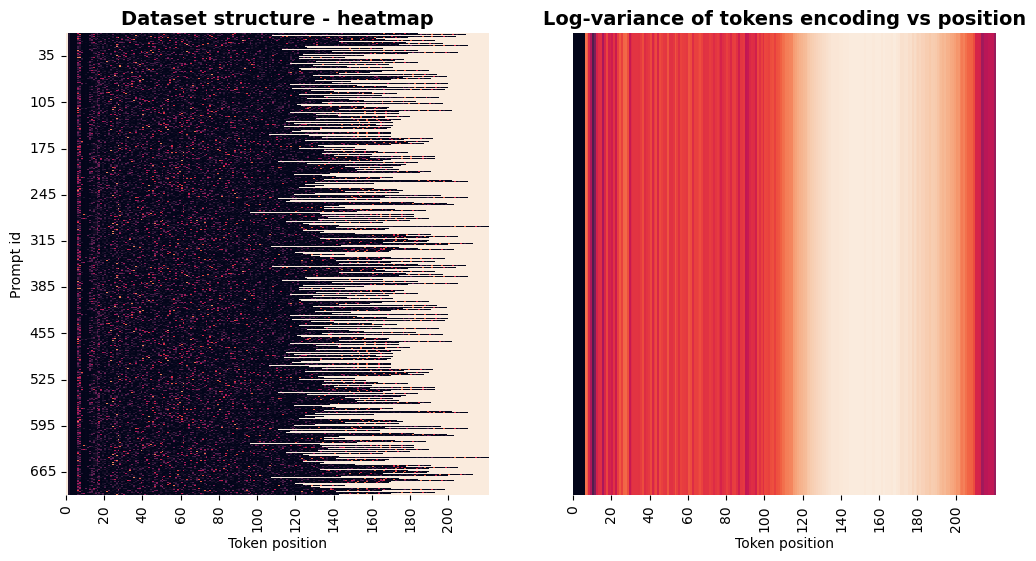

In [7]:
import matplotlib.pyplot as plt
from seaborn import heatmap
from copy import deepcopy
from torch import float32

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))

## ax1
heatmap(inputs['input_ids'].cpu(), ax=ax1, cbar=False)
ax1.set_title(
    'Dataset structure - heatmap',
    fontweight='bold',
    fontsize=14,
)
ax1.set_yticks([i*70 + 35 for i in range(10)])
ax1.set_yticklabels([i*70 + 35 for i in range(10)])
ax1.set_xticks([i*20 for i in range(11)])
ax1.set_xticklabels([i*20 for i in range(11)])
ax1.set_xlabel('Token position')
ax1.set_ylabel('Prompt id')

## ax2
temp: Tensor = deepcopy(inputs['input_ids'].cpu())
temp = temp.type(float32)

vars = temp.var(dim=0).log().clamp(min=15).unsqueeze(0)
ax2.set_title(
    'Log-variance of tokens encoding vs position',
    fontweight='bold',
    fontsize=14
)
heatmap(vars, ax=ax2, cbar=False)
ax2.set_yticks([])
ax2.set_xticks([i*20 for i in range(11)])
ax2.set_xticklabels([i*20 for i in range(11)])
ax2.set_xlabel('Token position')

plt.show()

In [12]:
_get_mps_status()

Recommended max memory usage for this machine: 24.96GB
Currently allocated MPS memory: 0.00GB - 0.01%


In [ ]:
########################################
### EXPERIMENT WITH BATCH SIZE = MAX ###
########################################

import time
from torch import inference_mode
from json import load

## DATA LOADING ##
FILE_PATH = '/Users/simone/Desktop/projects/llm-steering-experiment/datasets/anthropic/train/sycophancy.json'
with open(FILE_PATH, 'r') as f:
    data = load(f)

## DATA FORMATTING ##    
prompts_matching = [row['question'] + row['answer_matching_behavior'] for row in data]
prompts_not_matching = [row['question'] + row['answer_not_matching_behavior'] for row in data]
prompts = prompts_matching + prompts_not_matching
del prompts_matching, prompts_not_matching

inputs = llama_tokenizer(
    prompts,
    return_tensors='pt',
    padding = True,
)
inputs.to('mps')

## ASSIGN HOOKS TO LAYER ## 
hooks = HookForLanguageModelWithMemoryRecording()
handles = []

for name, module in llama_model.named_modules():
    if len(list(module.children())) == 0:
        handles.append(module.register_forward_pre_hook(hooks.pre_forward_hook))
        handles.append(module.register_forward_hook(hooks.forward_hook))

# print(f'total number of assigned hooks: {len(handles)}')

## COMPUTATION WITH HOOKS ## 
with inference_mode():
    t_0 = time.perf_counter()
    print('[INFO]: STARTING FORWARD PHASE W/HOOKS')
    llama_model(**inputs)
    t_end = time.perf_counter()
inputs.to('cpu')

print(f'\nMax memory used during forward phase with hooks: {hooks.peak_memory_usage_MB} MB')
print(f'Time needed to perform the forward phase {t_end - t_0} seconds')

## REMOVING THE HOOKS FROM THE MODEL
for hook in handles:
    hook.remove()
hooks._reset()

## PERFORMING COMPUTATION WITHOUT HOOKS - ON GPU
t_0 = time.perf_counter()
llama_model.to('mps')
inputs.to('mps')

with inference_mode():
    print('[INFO]: STARTING FORWARD PHASE W/O HOOKS, ON GPU')
    llama_model(**inputs)
    t_end = time.perf_counter()

print(f'\nMax memory used during forward phase without hooks, model on {llama_model.device}: {mps.current_allocated_memory() / (1024**2)} MB')
print(f'Time needed to perform the forward phase {t_end - t_0} seconds')

## RESTORING GPU INTERNAL STATUS
llama_model.to('cpu')
inputs.to('cpu')

## FINAL CHECK ON MPS USAGE: should return to configuration status ##
print()
_get_mps_status()

KeyboardInterrupt: 

In [7]:
_get_mps_status()

Recommended max memory usage for this machine: 24.96GB
Currently allocated MPS memory: 0.00GB - 0.00%


## **IMPROVING HOOKS DESIGN**
Apart from dynamic memory allocation, we are more interested in designing hooks that are capable of achieving retrieval of residual stream at different depth. This may not be *that* easy, mostly because the forward loop that is computed when calling `model.logits(**inputs)` is not a direct `torch.nn.Module.forward()` call, and I haven't dug into the source code looking for some sort of inheritance.

Hooks must not only be declared, but most importantly be assigned to singular layer. At this step we are mostly focused in detecting hooks after each residual operation (sum). This may be subject to change.

The following definition aims to introduce a debugging feature for these kind of objects.

In [1]:
import torch.mps as mps
import torch.cuda as cuda
from torch import Tensor, allclose
from torch.nn import Module
from typing import Any, Literal
from copy import deepcopy

Device = Literal['cuda', 'mps', 'cpu']

class _BaseHook:
    '''Base Hook is designed to support common features among all other hooks definition after inheritance. These include mostly debugging features that allow for some computation testing'''
    def __init__(self, debug=False, dynamic_memory=False) -> None:
        self._debug_mode: bool = debug
        self._dynamic_memory: bool = dynamic_memory
    ##

    @property
    def debug_mode(self):
        pass
    ##
    @debug_mode.getter
    def debug_mode(self):
        return self._debug_mode
    ##
    @debug_mode.setter
    def debug_mode(self, value: bool):
        if not isinstance(value, bool):
            raise ValueError('cannot assign non-boolean vector to debug_mode attribute')
        self._debug_mode = value
    ##

    @property
    def dynamic_memory(self):
        pass
    ##
    @dynamic_memory.getter
    def dynamic_memory(self):
        return self._dynamic_memory
    ##
    @dynamic_memory.setter
    def dynamic_memory(self, value: bool):
        if not isinstance(value, bool):
            raise ValueError('cannot assign non-boolean vector to dynamic_memory attribute')
        self._dynamic_memory = True
    ##

    def _debug(self):
        '''Sets internal state to "debug", causes the hook to print messages during inference tests'''
        self.debug_mode = True
    def _run(self):
        '''Sets internal state to "run", avoiding additional debugging messages in both forward and backwards call'''
        self.debug_mode = False
    ##

    def _dynamic_allocation(self):
        '''Changes internal state in order to dynamically load layers to GPU accelerator.'''
        self.dynamic_memory = True
    def _static_allocation(self):
        '''Changes internal state in order to handle allocation statically'''
        self.dynamic_memory = False
    ##

    def _device(self) -> Device:
        '''Returns the main GPU device used to accelerate computation, or 'cpu' is no GPU is found. Relies on `torch` detection methods'''
        if cuda.is_available():
            return 'cuda'
        elif mps.is_available():
            return 'mps'
        else:
            return 'cpu'  
    ##

    def pre_forward_hook(
            self,
            module: Module,
            input: Tensor,
    ):
        if self.debug_mode:
            print()
            print(f'[{module._get_name()}, pre-for]: received input {type(input)}')
            print(f'[{module._get_name()}, pre-for]: input shape: {input[0].shape}')
        if self.dynamic_memory:
            if self.debug_mode:
                print(f'[{module._get_name()}, pre-for]: moving layer to {self._device()}')
            module = module.to(self._device())
            mps.synchronize()
            mps.empty_cache()
    ##

    def forward_hook(
            self,
            module: Module,
            input: Tensor,
            output: Tensor
    ):
        if self.debug_mode:
            print(f'[{module._get_name()}, for]: resulted output: {type(output)}')
            print(f'[{module._get_name()}, for]: output shape: {output[0].shape}')
        if self._dynamic_memory:
            if self.debug_mode:
                print(f'[{module._get_name()}, for]: moving layer back to cpu')
            mps.synchronize()
            mps.empty_cache()
            module = module.to('cpu')
    ##

    # TODO: complete with these implementations, might be useful for fine-tuning
    def backward_hook(self):
        pass
##

class SteeringHook(_BaseHook):

    def __init__(self, injection_activation: Tensor, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)

        assert(isinstance(injection_activation, Tensor)), 'expected tensor as injector'
        # further assertion on shape of the tensor?
        self._inject = injection_activation
        if self.debug_mode:
            print(f'Assigned injection hook of shape {self._inject.shape}')
    ##


    def _test_if_input_changed(self,t1,t2,module) -> bool:
        '''Needed for debug in `pre_forward_hook()` call
        
        t1: steered_input, expected size=[B, TOKENS_NUM, EMBEDS_DIM]\n
        t2: non steered_input, expected size=[B, TOKENS_NUM, EMBEDS_DIM]
        '''
        
        print(f'[{module._get_name()}, _test_if_input_changed]: testing equivalence with \'tol=1e-4\', consider editing this value for any issue')
        return all([allclose(dim2, self._inject, atol=1e-4) for dim1 in t1-t2 for dim2 in dim1])
    ##

    def pre_forward_hook(self, module, input: tuple[Tensor, Any, Any]):
        '''Injects activations into residual stream'''
        super().pre_forward_hook(module, input)
        if self.debug_mode:
            print(f'[{module._get_name()}, pre-for]: injecting CAA vector')
            input_copy = deepcopy(input)
        
        # synchronize devices and cache orginal injection position
        inject_device_cache = self._inject.device
        self._inject = self._inject.to(input[0].device)
        edited_input = (input[0] + self._inject, *input[1:])
        self._inject.to(inject_device_cache)
        
        # eventual debug
        if self.debug_mode:
            if self._test_if_input_changed(edited_input[0], input_copy[0], module):
                pass
            else:
                RuntimeError(f'[{module._get_name()}, pre-for]: injection failed')

        return edited_input
    ##
##

We test these hooks by performing a brief computation on the LLama3.1 model. This way we also debug functionality of forward calls of `transformers` inherited models

In [2]:
## LOADING THE MODEL (TO CPU - STANDARD) ##
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
print(f'\nImporting model: {MODEL_NAME}')
llama_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path= MODEL_NAME,
    device_map = 'cpu',
)
llama_tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME
)


/Users/simone/miniconda3/envs/llm-steering/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Importing model: meta-llama/Llama-3.1-8B-Instruct


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 17256.61it/s]


In [1]:
## HOOKS DECLARATION
hooks_for_residual_stream = _BaseHook(debug=True, dynamic_memory=True) 
hooks_for_every_other_module = _BaseHook(debug=False, dynamic_memory=True) # we need to move 
try:
    [handle.remove() for handle in handles]
except Exception:
    pass

handles = []
for name, layer in llama_model.named_modules():
    if len(list(layer.children())) == 0:
        handles.append(layer.register_forward_pre_hook(hooks_for_every_other_module.pre_forward_hook))
        handles.append(layer.register_forward_hook(hooks_for_every_other_module.forward_hook))
for name, layer in llama_model.model.layers.named_children():
    handles.append(layer.register_forward_pre_hook(hooks_for_residual_stream.pre_forward_hook))
    handles.append(layer.register_forward_hook(hooks_for_residual_stream.forward_hook))
    print(f'{name}, {layer._get_name()}')
##

print(f'successfully introduced {len(handles)} hooks')

NameError: name '_BaseHook' is not defined

The following snippet demonstrates that current hooks design work, also allowing for a rather good parallelization whenever needed. One can try to test with different batches_size to check for parallelization effectiveness.

In [4]:
from torch import inference_mode
from json import load

## DATA LOADING ##
FILE_PATH = '/Users/simone/Desktop/projects/llm-steering-experiment/datasets/anthropic/train/sycophancy.json'
with open(FILE_PATH, 'r') as f:
    data = load(f)

test = [i['question'] for i in data[:20]]

llama_tokenizer.pad_token = llama_tokenizer.eos_token
inputs = llama_tokenizer(
    test,
    return_tensors='pt',
    padding=True
)

## TESTING INFERENCE
# print('[INFO]: Moving "llama_model" to mps'); llama_model.to('mps')
print('[INFO]: Moving "inputs" to mps'); inputs.to('mps')

print('[INFO]: Starting the forward phase')
with inference_mode():
    outs = llama_model(**inputs)

print('[INFO]: Forward computation ended')
# print('[INFO]: Moving "llama_model" to cpu'); llama_model.to('cpu')
print('[INFO]: Moving "inputs" to cpu'); inputs = inputs.to('cpu')
print('[INFO]: Moving "outs.logits" to cpu'); outs.logits = outs.logits.to('cpu')

[INFO]: Moving "inputs" to mps
[INFO]: Starting the forward phase

[LlamaDecoderLayer, pre-for]: received input <class 'tuple'>
[LlamaDecoderLayer, pre-for]: input shape: torch.Size([20, 207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer to mps
[LlamaDecoderLayer, pre-for]: resulted output: <class 'torch.Tensor'>
[LlamaDecoderLayer, pre-for]: output shape: torch.Size([207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer back to cpu

[LlamaDecoderLayer, pre-for]: received input <class 'tuple'>
[LlamaDecoderLayer, pre-for]: input shape: torch.Size([20, 207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer to mps
[LlamaDecoderLayer, pre-for]: resulted output: <class 'torch.Tensor'>
[LlamaDecoderLayer, pre-for]: output shape: torch.Size([207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer back to cpu

[LlamaDecoderLayer, pre-for]: received input <class 'tuple'>
[LlamaDecoderLayer, pre-for]: input shape: torch.Size([20, 207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer to mps

In [6]:
outs.logits.shape # SHAPE IS ALWAYS (BATCH, TOKENS_NUM, VOCAB_SIZE)

torch.Size([20, 207, 128256])

We also try to perform an injection test. The logic is the same as the previous test, only thing is that we also allow for an injection. We are not (yet) evaluating any metrics that regard evaluation on these experiments, but rather testing if the injection correctly occurs!

I picked steering vector at layer `l=15`. This has not a specific reason, again it is just testing whether we can be satisfied with the hook declaration.

In [3]:
import torch
from json import load


## DATA LOADING ##
FILE_PATH = '/Users/simone/Desktop/projects/llm-steering-experiment/datasets/anthropic/train/sycophancy.json'
with open(FILE_PATH, 'r') as f:
    data = load(f)

test = [i['question'] for i in data[:20]]

llama_tokenizer.pad_token = llama_tokenizer.eos_token
inputs = llama_tokenizer(
    test,
    return_tensors='pt',
    padding=True
)


## INJECTION VECTOR LOADING
INJECTION_PATH = '/Users/simone/Desktop/projects/llm-steering-experiment/steering-vectors/meta-llama/Llama-3.1-8B-Instruct/sycophancy.pt'
l=15 # layer to steer
all_injections = torch.load(INJECTION_PATH, weights_only=False)
injection_vector = all_injections[l]

## HOOKS DECLARATION
hooks_for_steering = SteeringHook(debug=True, dynamic_memory=True, injection_activation=injection_vector)
hooks_for_residual_stream = _BaseHook(debug=True, dynamic_memory=True) 
hooks_for_every_other_module = _BaseHook(debug=False, dynamic_memory=True) # we need to move 
try:
    [handle.remove() for handle in handles]
except Exception:
    pass

handles = []
for name, layer in llama_model.named_modules():
    if len(list(layer.children())) == 0:
        handles.append(layer.register_forward_pre_hook(hooks_for_every_other_module.pre_forward_hook))
        handles.append(layer.register_forward_hook(hooks_for_every_other_module.forward_hook))
for index, (name, layer) in enumerate(llama_model.model.layers.named_children()):
    if index!=l:
        handles.append(layer.register_forward_pre_hook(hooks_for_residual_stream.pre_forward_hook))
        handles.append(layer.register_forward_hook(hooks_for_residual_stream.forward_hook))
    else:
        handles.append(layer.register_forward_pre_hook(hooks_for_steering.pre_forward_hook))
        handles.append(layer.register_forward_hook(hooks_for_steering.forward_hook))
##

print(f'successfully introduced {len(handles)} hooks')




## TESTING INFERENCE
# print('[INFO]: Moving "llama_model" to mps'); llama_model.to('mps')
print('[INFO]: Moving "inputs" to mps'); inputs.to('mps')

print('[INFO]: Starting the forward phase')
with torch.inference_mode():
    outs = llama_model(**inputs)

print('[INFO]: Forward computation ended')
# print('[INFO]: Moving "llama_model" to cpu'); llama_model.to('cpu')
print('[INFO]: Moving "inputs" to cpu'); inputs = inputs.to('cpu')
print('[INFO]: Moving "outs.logits" to cpu'); outs.logits = outs.logits.to('cpu')

Assigned injection hook of shape torch.Size([4096])
successfully introduced 712 hooks
[INFO]: Moving "inputs" to mps
[INFO]: Starting the forward phase

[LlamaDecoderLayer, pre-for]: received input <class 'tuple'>
[LlamaDecoderLayer, pre-for]: input shape: torch.Size([20, 207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer to mps
[LlamaDecoderLayer, for]: resulted output: <class 'torch.Tensor'>
[LlamaDecoderLayer, for]: output shape: torch.Size([207, 4096])
[LlamaDecoderLayer, for]: moving layer back to cpu

[LlamaDecoderLayer, pre-for]: received input <class 'tuple'>
[LlamaDecoderLayer, pre-for]: input shape: torch.Size([20, 207, 4096])
[LlamaDecoderLayer, pre-for]: moving layer to mps
[LlamaDecoderLayer, for]: resulted output: <class 'torch.Tensor'>
[LlamaDecoderLayer, for]: output shape: torch.Size([207, 4096])
[LlamaDecoderLayer, for]: moving layer back to cpu

[LlamaDecoderLayer, pre-for]: received input <class 'tuple'>
[LlamaDecoderLayer, pre-for]: input shape: torch.Size([20,

In [5]:
outs.logits.shape

torch.Size([20, 207, 128256])

## **A BRIEF TEST WITH DIMENSIONALITY**
This is stupid, but I needed it to understand how to handle different sizes and shapes when trying to parallelize computation

In [54]:
from torch import randn, stack

BATCH_SIZE, TOKEN_NUM, EMBEDDING_DIM = 10, 150, 4096
LAYERS_NUM = 32

already_extracted = 10
dynamic_mean = randn(LAYERS_NUM, EMBEDDING_DIM)
fake_output = randn(BATCH_SIZE, LAYERS_NUM, TOKEN_NUM, EMBEDDING_DIM)
print(fake_output.shape)

# questa operazione si fa assumendo che il carattere che vado ad estrarre sia lo stesso per ogni batch -> non è così
store_batch_size = fake_output.shape[0]
token_to_extract = [130+i for i in range(10)] # example
assert len(token_to_extract) == store_batch_size, f'{store_batch_size} vs {len(token_to_extract)}'
fake_output = stack([depth[:,token_to_extract[i]] for i, depth in enumerate(fake_output)]) # removes depth at TOKEN_NUM
fake_output = fake_output.sum(dim=0) # removes depth at BATCH_SIZE
print(fake_output.shape)


dynamic_mean = (dynamic_mean * already_extracted + fake_output) / (already_extracted+1)
already_extracted += 1
print(dynamic_mean.shape)
print(already_extracted)


torch.Size([10, 32, 150, 4096])
torch.Size([32, 4096])
torch.Size([32, 4096])
11


Another test that I need to run is how torch handles summation over tensors of different shapes. Again, I get this is basic stuff for many other, but for me was needed since I'm not quite to used to manually debug those kind of stuff ;(

In [24]:
import torch

original = torch.randn((10, 100, 4096), dtype=torch.float32)
injection = torch.randn(4096, dtype=torch.float32)
steered = original + injection


all([torch.equal(dim2, injection) for dim1 in steered-original for dim2 in dim1])
print(f'injection={injection}')
[(torch.allclose(dim2, injection, atol=.001), dim2) for dim1 in steered-original for dim2 in dim1]
# [(torch.testing.assert_close(dim2, injection), dim2) for dim1 in steered-original for dim2 in dim1]

injection=tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])


[(True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.1880,  1.5210,  0.0213])),
 (True, tensor([ 0.2225, -0.9059, -0.5772,  ...,  0.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


x = torch.randn((2,10), device='mps')
class TestModule(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.linear = nn.ModuleList([nn.Linear(10,10) for _ in range(3)])
    ##

    def forward(self, x):
        for layer in self.linear:
            x = layer(x)
    ##
##

steering = torch.randn(10)
test_hooks = _BaseHook(debug=True, dynamic_memory=True)
injection_hooks = SteeringHook(debug=True, dynamic_memory=True, injection_activation=steering)

net = TestModule()
cache = []
for i, (name, module) in enumerate(net.linear.named_modules()):
    if i!=1:
        cache.append(module.register_forward_pre_hook(test_hooks.pre_forward_hook))
        cache.append(module.register_forward_hook(test_hooks.forward_hook))
    else:
        cache.append(module.register_forward_pre_hook(injection_hooks.pre_forward_hook))
        cache.append(module.register_forward_hook(injection_hooks.forward_hook))
    print(name)
##

y = net(x)

Assigned injection hook of shape torch.Size([10])

0
1
2

[Linear, pre-for]: received input <class 'tuple'>
[Linear, pre-for]: input shape: torch.Size([2, 10])
[Linear, pre-for]: moving layer to mps
[Linear, pre-for]: injecting CAA vector
[Linear, _test_if_input_changed]: testing equivalence with 'tol=1e-4', consider editing this value for any issue
[Linear, for]: resulted output: <class 'torch.Tensor'>
[Linear, for]: output shape: torch.Size([10])
[Linear, for]: moving layer back to cpu

[Linear, pre-for]: received input <class 'tuple'>
[Linear, pre-for]: input shape: torch.Size([2, 10])
[Linear, pre-for]: moving layer to mps
[Linear, for]: resulted output: <class 'torch.Tensor'>
[Linear, for]: output shape: torch.Size([10])
[Linear, for]: moving layer back to cpu

[Linear, pre-for]: received input <class 'tuple'>
[Linear, pre-for]: input shape: torch.Size([2, 10])
[Linear, pre-for]: moving layer to mps
[Linear, for]: resulted output: <class 'torch.Tensor'>
[Linear, for]: output shape

In [7]:
cache